In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

# Unggah file xlsx secara interaktif
uploaded = files.upload()

# Membaca data dari sheet 'Data'
df_raw = pd.read_excel('3TIC_09_StackOverflowSurvey2025.xlsx', sheet_name='Data')
print(f"Ukuran data mentah: {df_raw.shape[0]} baris, {df_raw.shape[1]} kolom")

Saving 3TIC_09_StackOverflowSurvey2025.xlsx to 3TIC_09_StackOverflowSurvey2025.xlsx
Ukuran data mentah: 48446 baris, 172 kolom


In [18]:
# 1. Pilih kolom utama
cols = ['ConvertedCompYearly', 'WorkExp', 'RemoteWork', 'Country']
df_filtered = df_raw[cols].dropna(subset=['ConvertedCompYearly', 'WorkExp', 'RemoteWork']).copy()

# 2. Tangani Outlier Gaji menggunakan Trimming Persentil (1% - 99%)
p1 = df_filtered['ConvertedCompYearly'].quantile(0.01)
p99 = df_filtered['ConvertedCompYearly'].quantile(0.99)

df_clean = df_filtered[(df_filtered['ConvertedCompYearly'] >= p1) & (df_filtered['ConvertedCompYearly'] <= p99)].copy()

print(f"Jumlah data awal berfilter: {len(df_filtered)} baris")
print(f"Batas bawah gaji (Persentil 1%): ${p1:,.2f}")
print(f"Batas atas gaji (Persentil 99%): ${p99:,.2f}")
print(f"Jumlah data bersih setelah trimming outlier: {len(df_clean)} baris")

Jumlah data awal berfilter: 20374 baris
Batas bawah gaji (Persentil 1%): $93.00
Batas atas gaji (Persentil 99%): $440,856.00
Jumlah data bersih setelah trimming outlier: 19968 baris


In [19]:
# Statistik Deskriptif Gaji dan Pengalaman Kerja
stats_num = df_clean[['ConvertedCompYearly', 'WorkExp']].describe().T
stats_num['median'] = df_clean[['ConvertedCompYearly', 'WorkExp']].median()
stats_num = stats_num[['count', 'mean', 'median', 'std', 'min', 'max']]
print("=== STATISTIK DESKRIPTIF VARIABEL NUMERIK ===")
print(stats_num.round(2))

# Distribusi Frekuensi Pola Kerja (RemoteWork)
print("\n=== DISTRIBUSI POLA KERJA (RemoteWork) ===")
remote_freq = df_clean['RemoteWork'].value_counts()
remote_pct = df_clean['RemoteWork'].value_counts(normalize=True) * 100
df_remote = pd.DataFrame({'Jumlah': remote_freq, 'Persentase (%)': remote_pct.round(2)})
print(df_remote)

=== STATISTIK DESKRIPTIF VARIABEL NUMERIK ===
                       count      mean   median       std   min       max
ConvertedCompYearly  19968.0  90226.54  76570.0  69077.79  93.0  440856.0
WorkExp              19968.0     13.25     11.0      9.68   1.0     100.0

=== DISTRIBUSI POLA KERJA (RemoteWork) ===
                                                    Jumlah  Persentase (%)
RemoteWork                                                                
Remote                                                6786           33.98
Hybrid (some remote, leans heavy to in-person)        3964           19.85
Hybrid (some in-person, leans heavy to flexibil...    3669           18.37
In-person                                             2946           14.75
Your choice (very flexible, you can come in whe...    2603           13.04


In [20]:
# Analisis Gaji dan Pengalaman Kerja Berdasarkan Pola Kerja
bivariate_summary = df_clean.groupby('RemoteWork').agg(
    Jumlah_Responden=('ConvertedCompYearly', 'count'),
    Rata2_Gaji=('ConvertedCompYearly', 'mean'),
    Median_Gaji=('ConvertedCompYearly', 'median'),
    Rata2_Pengalaman=('WorkExp', 'mean'),
    Median_Pengalaman=('WorkExp', 'median')
).reset_index()

print("=== RINGKASAN BIVARIAT BERDASARKAN POLA KERJA ===")
print(bivariate_summary.round(2))

=== RINGKASAN BIVARIAT BERDASARKAN POLA KERJA ===
                                          RemoteWork  Jumlah_Responden  \
0  Hybrid (some in-person, leans heavy to flexibi...              3669   
1     Hybrid (some remote, leans heavy to in-person)              3964   
2                                          In-person              2946   
3                                             Remote              6786   
4  Your choice (very flexible, you can come in wh...              2603   

   Rata2_Gaji  Median_Gaji  Rata2_Pengalaman  Median_Pengalaman  
0    90430.99      81210.0             13.58               11.0  
1    87849.86      73966.0             12.50               10.0  
2    66505.25      48000.0             10.72                7.0  
3   103149.65      89853.0             14.51               12.0  
4    86714.30      76484.0             13.49               11.0  


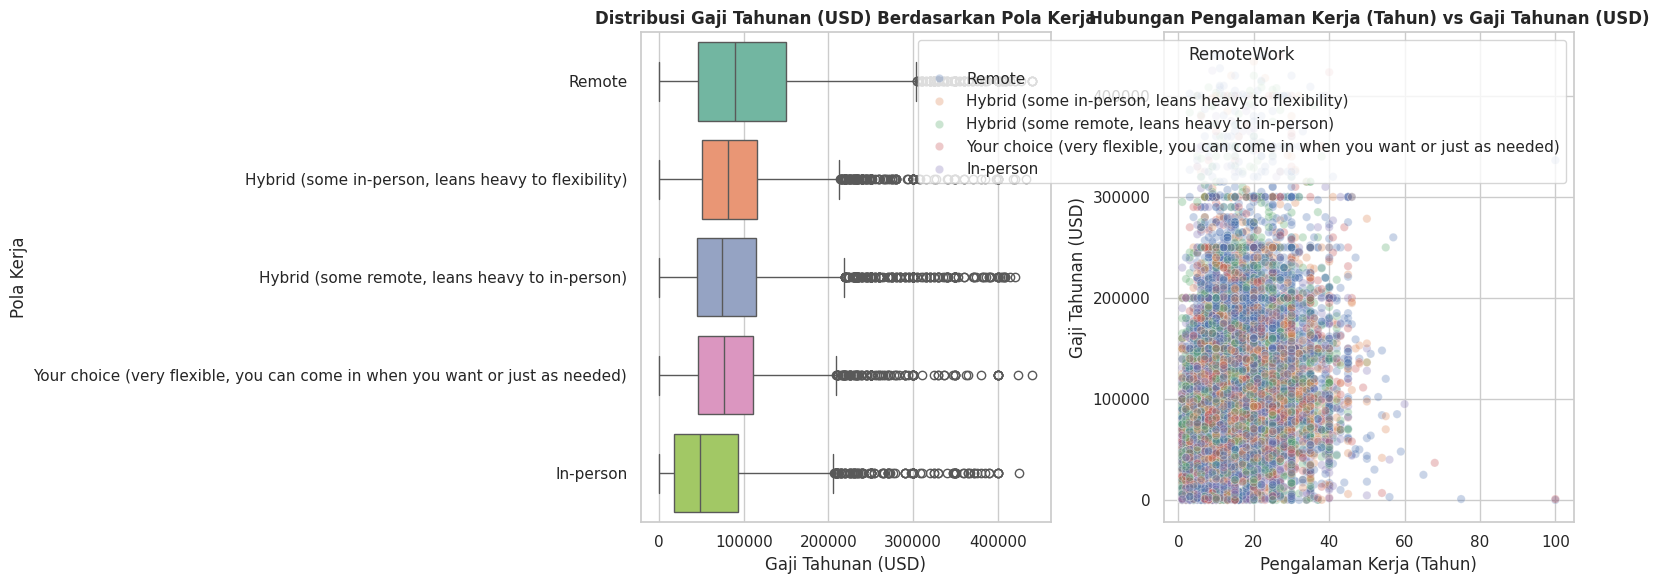

In [23]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Boxplot Gaji Berdasarkan RemoteWork
sns.boxplot(
    data=df_clean,
    y='RemoteWork',
    x='ConvertedCompYearly',
    hue='RemoteWork',  # Disesuaikan agar warning hilang
    legend=False,
    ax=axes[0],
    palette='Set2',
)
axes[0].set_title(
    'Distribusi Gaji Tahunan (USD) Berdasarkan Pola Kerja',
    fontsize=12,
    fontweight='bold',
)
axes[0].set_xlabel('Gaji Tahunan (USD)')
axes[0].set_ylabel('Pola Kerja')

# Plot 2: Scatter Plot Pengalaman Kerja vs Gaji
sns.scatterplot(
    data=df_clean,
    x='WorkExp',
    y='ConvertedCompYearly',
    hue='RemoteWork',
    alpha=0.3,
    ax=axes[1],
)
axes[1].set_title(
    'Hubungan Pengalaman Kerja (Tahun) vs Gaji Tahunan (USD)',
    fontsize=12,
    fontweight='bold',
)
axes[1].set_xlabel('Pengalaman Kerja (Tahun)')
axes[1].set_ylabel('Gaji Tahunan (USD)')

plt.tight_layout()
plt.savefig('visualisasi_stackoverflow_2025.png', dpi=300)
plt.show()